# Ejercicio PCA (Principal Component Analysis)
En este ejercicio voy a trabajar con un dataset de información de ciudadanos: estado civil, número de hijos, gastos, ingresos, etc. El objetivo (target) es predecir si el ciudadano va a **alquilar o comprar** una vivienda, utilizando PCA para reducir la dimensionalidad antes de aplicar un clasificador.

### Importamos librerías
Principales librerías que usaré durante el notebook.

In [16]:
# Importo todas las librerías que voy a necesitar en este notebook
import pandas as pd                          # Manejo de datos en tablas
import numpy as np                           # Operaciones numéricas
import matplotlib.pyplot as plt              # Gráficos básicos
import seaborn as sns                        # Gráficos estadísticos avanzados

from sklearn.preprocessing import StandardScaler       # Estandarización de datos
from sklearn.decomposition import PCA                  # Algoritmo PCA
from sklearn.model_selection import train_test_split, GridSearchCV  # División y búsqueda de hiperparámetros
from sklearn.pipeline import Pipeline                  # Para encadenar pasos de ML
from sklearn.linear_model import LogisticRegression    # Clasificador logístico
from sklearn.ensemble import RandomForestClassifier    # Clasificador basado en árboles
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay  # Métricas

import joblib                                # Para guardar el modelo entrenado
import warnings
warnings.filterwarnings('ignore')

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [17]:
# Cargo el dataset
df = pd.read_csv('/Users/andoni/2026-02-BILBAO-FT-Data-Science/3-Machine_Learning/2-No_Supervisado/2-PCA/Practica/data/comprar_alquilar.csv')

# Primeras filas para ver cómo está estructurado
print('Primeras filas:')
display(df.head())

# Dimensiones del dataset
print(f'\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

# Tipos de datos de cada columna
print('\nTipos de datos:')
print(df.dtypes)

# Estadísticas descriptivas: media, min, max, percentiles...
print('\nEstadísticas descriptivas:')
display(df.describe())

# Missings: ¿hay valores faltantes?
print('\nValores nulos por columna:')
print(df.isnull().sum())

# Distribución del target (comprar): cuántos 1s y 0s hay
print('\nDistribución del target (comprar):')
print(df['comprar'].value_counts())

Primeras filas:


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1



Dimensiones: 202 filas x 10 columnas

Tipos de datos:
ingresos          int64
gastos_comunes    int64
pago_coche        int64
gastos_otros      int64
ahorros           int64
vivienda          int64
estado_civil      int64
hijos             int64
trabajo           int64
comprar           int64
dtype: object

Estadísticas descriptivas:


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000



Valores nulos por columna:
ingresos          0
gastos_comunes    0
pago_coche        0
gastos_otros      0
ahorros           0
vivienda          0
estado_civil      0
hijos             0
trabajo           0
comprar           0
dtype: int64

Distribución del target (comprar):
comprar
0    135
1     67
Name: count, dtype: int64


### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

Variables predictoras: ['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros', 'vivienda', 'estado_civil', 'hijos', 'trabajo']


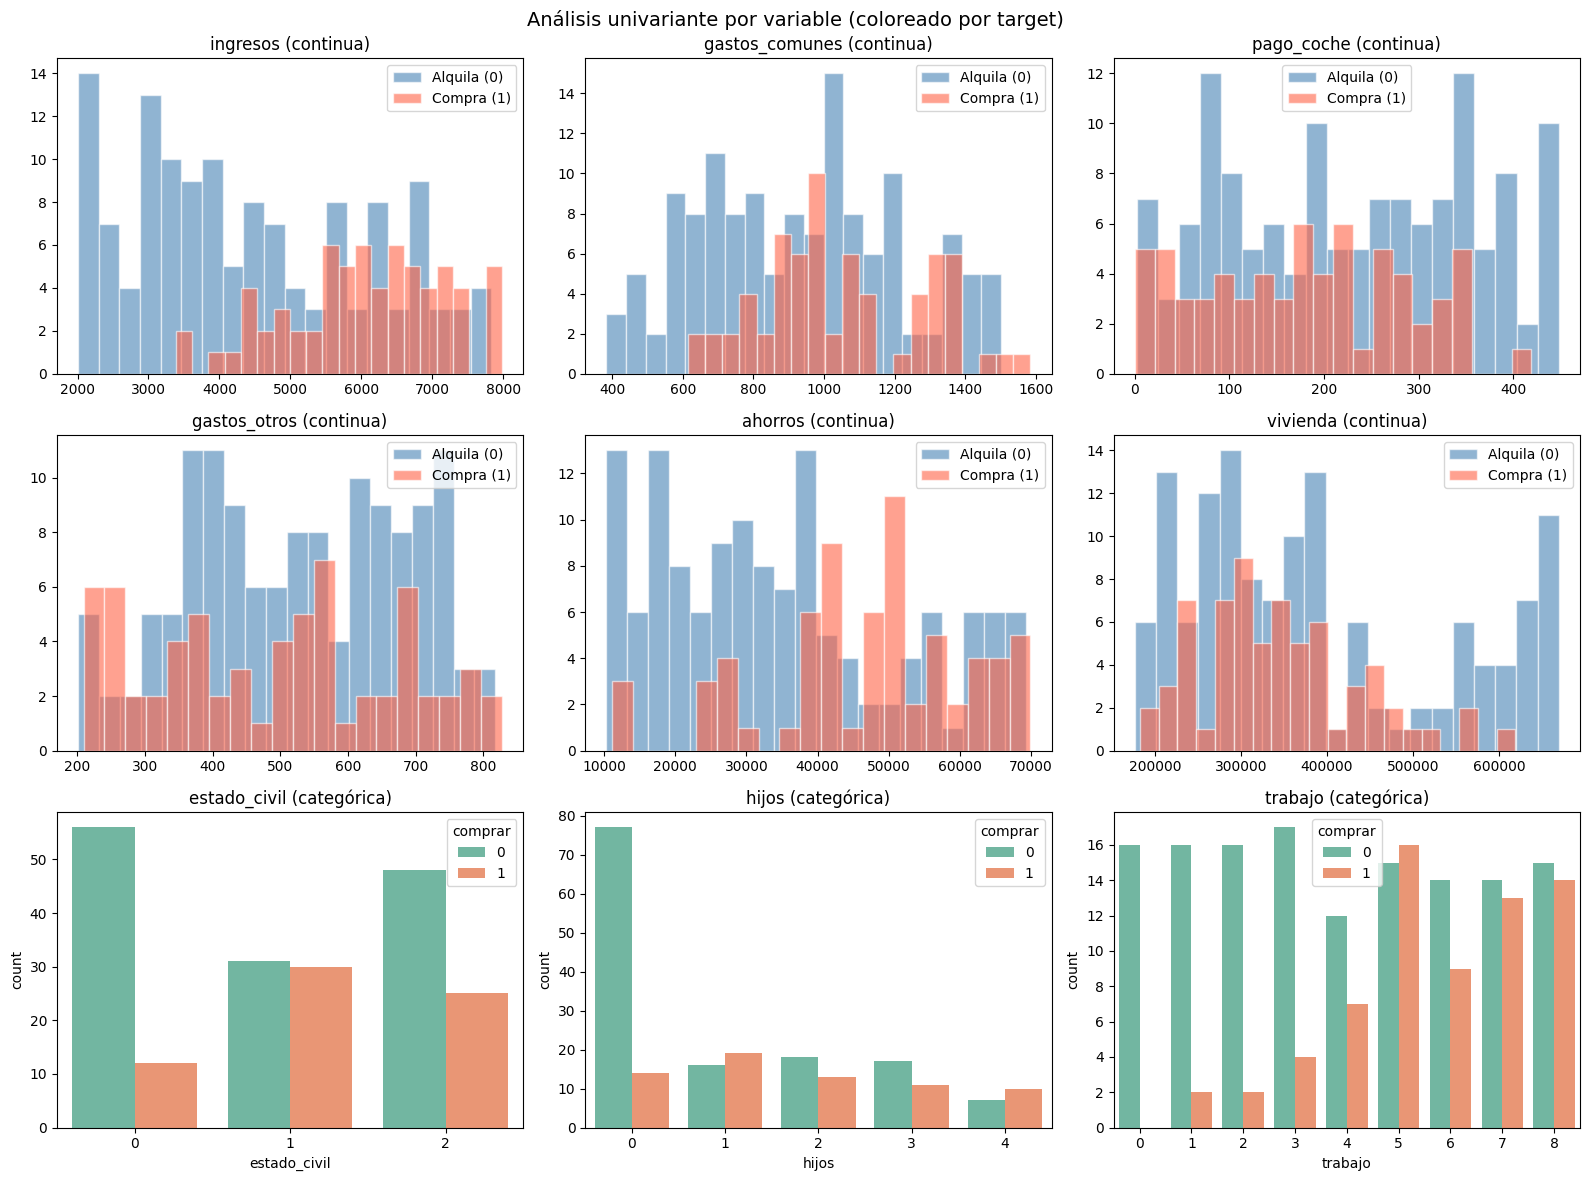

In [18]:
# Separo las features (variables predictoras) del target
# El target es 'comprar': 1 = compra, 0 = alquila
target = 'comprar'
features = [col for col in df.columns if col != target]

print(f'Variables predictoras: {features}')

# Análisis univariante: histograma de cada variable, coloreado por el valor del target
# Esto me permite ver si hay variables que separan bien los dos grupos
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    # Si la variable tiene pocos valores únicos, uso un boxplot
    if df[col].nunique() <= 10:
        sns.countplot(data=df, x=col, hue=target, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} (categórica)')
    else:
        # Si es continua, uso un histograma separado por target
        for val, color, label in zip([0, 1], ['steelblue', 'tomato'], ['Alquila (0)', 'Compra (1)']):
            axes[i].hist(df[df[target] == val][col], bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
        axes[i].set_title(f'{col} (continua)')
        axes[i].legend()

# Oculto ejes sobrantes si los hay
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Análisis univariante por variable (coloreado por target)', fontsize=14)
plt.tight_layout()
plt.show()

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [19]:
# Separo features y target
X = df[features]   # Todas las variables predictoras
y = df[target]     # La variable a predecir (0=alquila, 1=compra)

# Estandarizo: media=0, std=1 en cada variable
# Esto es necesario porque el PCA es sensible a la escala:
# sin escalar, una variable en miles dominaría sobre una variable en decimales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convierto de array a DataFrame para mayor comodidad
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('Datos estandarizados correctamente.')
print(f'Media por columna (debe ser ~0):')
print(X_scaled_df.mean().round(5))
print(f'\nDesviación típica por columna (debe ser ~1):')
print(X_scaled_df.std().round(5))

Datos estandarizados correctamente.
Media por columna (debe ser ~0):
ingresos         -0.0
gastos_comunes    0.0
pago_coche        0.0
gastos_otros     -0.0
ahorros           0.0
vivienda         -0.0
estado_civil     -0.0
hijos             0.0
trabajo           0.0
dtype: float64

Desviación típica por columna (debe ser ~1):
ingresos          1.00248
gastos_comunes    1.00248
pago_coche        1.00248
gastos_otros      1.00248
ahorros           1.00248
vivienda          1.00248
estado_civil      1.00248
hijos             1.00248
trabajo           1.00248
dtype: float64


## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [20]:
# Aplico PCA con 9 componentes (tantos como variables hay en el dataset)
# Esto me permite ver cuánta varianza aporta cada componente antes de decidir cuántos conservar
n_componentes = 9
pca = PCA(n_components=n_componentes)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA aplicado con {n_componentes} componentes.')
print(f'Shape del dataset transformado: {X_pca.shape}')

PCA aplicado con 9 componentes.
Shape del dataset transformado: (202, 9)


### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [21]:
# 1. Varianza explicada por cada componente individualmente
varianza_individual = pca.explained_variance_ratio_
print('1. Varianza explicada por cada PC individualmente:')
for i, v in enumerate(varianza_individual):
    print(f'   PC{i+1}: {v*100:.2f}%')

# 2. Varianza acumulada: cuánto explico en total usando los primeros N componentes
varianza_acumulada = np.cumsum(varianza_individual)
print('\n2. Varianza acumulada (de PC1 hacia adelante):')
for i, v in enumerate(varianza_acumulada):
    print(f'   PC1 a PC{i+1}: {v*100:.2f}%')

# 3. Varianza con sólo 5 componentes
varianza_5_componentes = varianza_acumulada[4]  # índice 4 = 5º componente
print(f'\n3. Con sólo 5 componentes explico el {varianza_5_componentes*100:.2f}% de la varianza original.')

1. Varianza explicada por cada PC individualmente:
   PC1: 29.91%
   PC2: 23.29%
   PC3: 11.71%
   PC4: 10.69%
   PC5: 9.64%
   PC6: 5.63%
   PC7: 4.15%
   PC8: 3.02%
   PC9: 1.97%

2. Varianza acumulada (de PC1 hacia adelante):
   PC1 a PC1: 29.91%
   PC1 a PC2: 53.21%
   PC1 a PC3: 64.92%
   PC1 a PC4: 75.61%
   PC1 a PC5: 85.24%
   PC1 a PC6: 90.87%
   PC1 a PC7: 95.02%
   PC1 a PC8: 98.03%
   PC1 a PC9: 100.00%

3. Con sólo 5 componentes explico el 85.24% de la varianza original.


### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

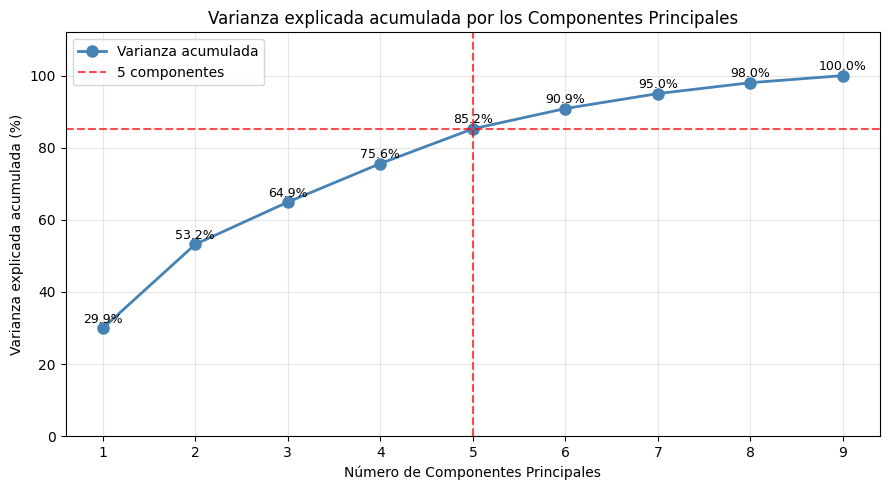

In [22]:
# Diagrama de líneas: eje X = número de componentes, eje Y = varianza acumulada explicada (%)
# Este gráfico me ayuda a decidir cuántos PCs conservar (busco el "codo" de la curva)
plt.figure(figsize=(9, 5))
plt.plot(range(1, n_componentes+1), varianza_acumulada * 100,
         marker='o', markersize=8, linewidth=2, color='steelblue', label='Varianza acumulada')

# Marco el punto de 5 componentes
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='5 componentes')
plt.axhline(y=varianza_acumulada[4]*100, color='red', linestyle='--', alpha=0.7)

# Añado etiquetas con el % en cada punto
for i, v in enumerate(varianza_acumulada):
    plt.text(i+1, v*100 + 1.5, f'{v*100:.1f}%', ha='center', fontsize=9)

plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza explicada acumulada (%)')
plt.title('Varianza explicada acumulada por los Componentes Principales')
plt.xticks(range(1, n_componentes+1))
plt.ylim(0, 112)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

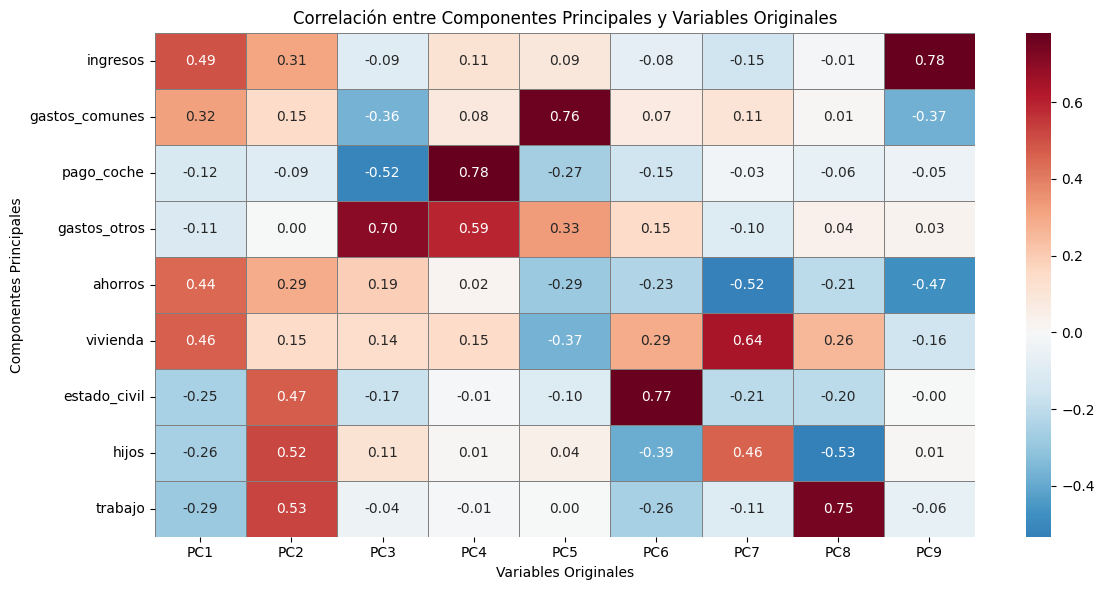

Interpretación: los valores más altos (en rojo) o más bajos (en azul) indican
qué variables originales tienen más peso en cada Componente Principal.


In [23]:
# pca.components_ es una matriz de forma (n_componentes x n_features)
# Cada fila es un PC y cada columna es una variable original
# Los valores representan el peso/contribución de cada variable en ese PC
# (similares a correlaciones: valores altos en absoluto = variable importante para ese PC)

componentes_df = pd.DataFrame(
    pca.components_,
    columns=features,
    index=[f'PC{i+1}' for i in range(n_componentes)]
)

# Mapa de calor: me permite ver qué variables originales "pesan más" en cada componente
plt.figure(figsize=(12, 6))
sns.heatmap(componentes_df.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, linecolor='gray')
plt.title('Correlación entre Componentes Principales y Variables Originales')
plt.xlabel('Variables Originales')
plt.ylabel('Componentes Principales')
plt.tight_layout()
plt.show()

print('Interpretación: los valores más altos (en rojo) o más bajos (en azul) indican')
print('qué variables originales tienen más peso en cada Componente Principal.')

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

In [24]:
# 1. DIVIDO en train (80%) y test (20%)
# Train: para que el modelo aprenda; Test: para evaluar si generaliza bien
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% para test
    random_state=42,       # Semilla para reproducibilidad
    stratify=y             # Mantengo la proporción de clases en ambas particiones
)
print(f'Tamaño train: {X_train.shape[0]} registros')
print(f'Tamaño test:  {X_test.shape[0]} registros')

Tamaño train: 161 registros
Tamaño test:  41 registros


In [25]:
# 2. CREO EL PIPELINE con 3 pasos encadenados:
#    Paso 1 - StandardScaler: estandariza los datos (media=0, std=1)
#    Paso 2 - PCA (5 componentes): reduce la dimensionalidad
#    Paso 3 - LogisticRegression: clasificador que predice 0 o 1
#
# Un Pipeline garantiza que el scaler y el PCA se entrenen SOLO con train
# y que luego se apliquen correctamente a test, evitando data leakage

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# 3. ENTRENO el pipeline con los datos de entrenamiento
pipeline.fit(X_train, y_train)
print('Pipeline entrenado correctamente.')

Pipeline entrenado correctamente.


In [26]:
# 4. PREDIGO con los datos de test
y_pred_train = pipeline.predict(X_train)  # Predicciones en train (para comparar)
y_pred_test  = pipeline.predict(X_test)   # Predicciones en test (evaluación real)

# 5. CALCULO EL ACCURACY: porcentaje de predicciones correctas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

print(f'Accuracy en TRAIN: {acc_train*100:.2f}%')
print(f'Accuracy en TEST:  {acc_test*100:.2f}%')

# Si train >> test, hay overfitting (el modelo memoriza en lugar de aprender)
if acc_train - acc_test > 0.10:
    print('⚠️  Posible overfitting: accuracy en train mucho mayor que en test.')
else:
    print('✅  No parece haber overfitting significativo.')

Accuracy en TRAIN: 80.12%
Accuracy en TEST:  73.17%
✅  No parece haber overfitting significativo.


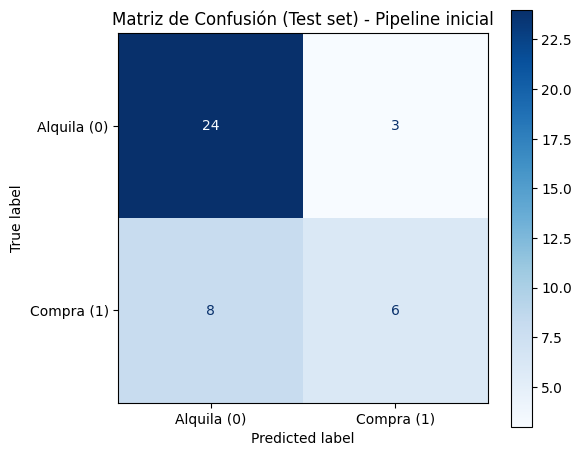

In [27]:
# 6. MATRIZ DE CONFUSIÓN
# Muestra cuántos casos clasifiqué bien (diagonal) y mal (fuera de la diagonal)
# Filas = clase real; Columnas = clase predicha

cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alquila (0)', 'Compra (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusión (Test set) - Pipeline inicial')
plt.tight_layout()
plt.show()

In [28]:
# 7 & 8. GRIDSEARCH: busco la mejor combinación de hiperparámetros automáticamente
#
# Voy a probar:
#   - pca__n_components: cuántos PCs usar (3, 5, 7, 9)
#   - clf__C: parámetro de regularización de la regresión logística (más pequeño = más simple)
#   - clf__solver: algoritmo de optimización
#
# También pruebo con RandomForest por si da mejor resultado

# Pipeline con RandomForestClassifier para comparar
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('clf', RandomForestClassifier(random_state=42))
])

# Parámetros que quiero explorar en el GridSearch
param_grid = [
    # Combinaciones con LogisticRegression
    {
        'pca__n_components': [3, 5, 7, 9],
        'clf': [LogisticRegression(max_iter=1000, random_state=42)],
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__solver': ['lbfgs', 'liblinear']
    },
    # Combinaciones con RandomForest
    {
        'pca__n_components': [3, 5, 7, 9],
        'clf': [RandomForestClassifier(random_state=42)],
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [None, 5, 10]
    }
]

# cv=5: validación cruzada de 5 pliegues para evaluar cada combinación
# scoring='accuracy': optimizo por porcentaje de acierto
grid_search = GridSearchCV(
    pipeline_rf,        # el pipeline base
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,          # usa todos los núcleos del procesador disponibles
    verbose=1
)

# Entreno el GridSearch (prueba todas las combinaciones)
grid_search.fit(X_train, y_train)

print(f'\nMejor combinación de parámetros encontrada:')
print(grid_search.best_params_)
print(f'\nMejor accuracy en validación cruzada (train): {grid_search.best_score_*100:.2f}%')

Fitting 5 folds for each of 68 candidates, totalling 340 fits

Mejor combinación de parámetros encontrada:
{'clf': LogisticRegression(max_iter=1000, random_state=42), 'clf__C': 1, 'clf__solver': 'liblinear', 'pca__n_components': 9}

Mejor accuracy en validación cruzada (train): 95.02%


Mejor modelo — Accuracy TRAIN: 96.89%
Mejor modelo — Accuracy TEST:  90.24%


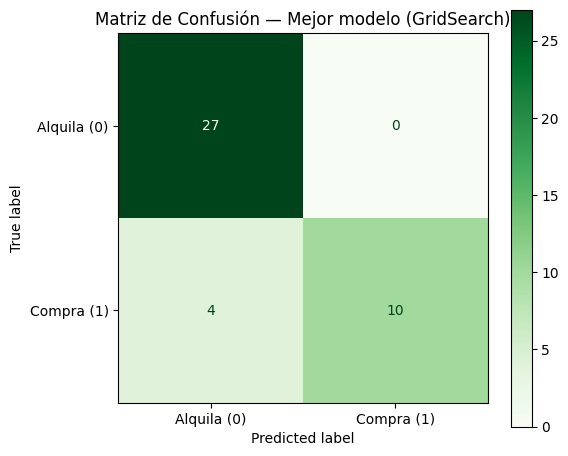

In [29]:
# Evalúo el mejor modelo sobre el test
mejor_modelo = grid_search.best_estimator_
y_pred_mejor_train = mejor_modelo.predict(X_train)
y_pred_mejor_test  = mejor_modelo.predict(X_test)

acc_mejor_train = accuracy_score(y_train, y_pred_mejor_train)
acc_mejor_test  = accuracy_score(y_test,  y_pred_mejor_test)

print(f'Mejor modelo — Accuracy TRAIN: {acc_mejor_train*100:.2f}%')
print(f'Mejor modelo — Accuracy TEST:  {acc_mejor_test*100:.2f}%')

# Matriz de confusión del mejor modelo
cm_mejor = confusion_matrix(y_test, y_pred_mejor_test)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mejor, display_labels=['Alquila (0)', 'Compra (1)'])
disp.plot(cmap='Greens', ax=ax)
ax.set_title('Matriz de Confusión — Mejor modelo (GridSearch)')
plt.tight_layout()
plt.show()

In [30]:
# 9. GUARDO EL MEJOR MODELO en disco con joblib
# Así puedo cargarlo en otro momento sin volver a entrenar
joblib.dump(mejor_modelo, 'mejor_modelo_pca_comprar_alquilar.pkl')
print('✅ Mejor modelo guardado como "mejor_modelo_pca_comprar_alquilar.pkl"')

# Para cargarlo más adelante:
# modelo_cargado = joblib.load('mejor_modelo_pca_comprar_alquilar.pkl')
# predicciones = modelo_cargado.predict(nuevos_datos)

✅ Mejor modelo guardado como "mejor_modelo_pca_comprar_alquilar.pkl"
